In [81]:
import pandas as pd

In [82]:
# Baca file CSV
df = pd.read_csv("data_news/merged_with_vector_same_day.csv")
df_new = df[['date_only', 'vec_judul','Status']].copy()
df_new['date_only'] = pd.to_datetime(df_new['date_only'], errors='coerce')
df_new['day'] = (df_new['date_only'].dt.dayofweek + 1 ) / 10 # jadi Senin=1, Minggu=7
df_new = df_new[['day', 'vec_judul','Status']]

In [83]:
df_new

,day,vec_judul,Status
0,0.1,-0.2764633893966675 0.19038888812065125 0.9985...,GOOD
1,0.1,-0.5665766000747681 0.07860113680362701 0.9901...,GOOD
2,0.2,-0.3197837471961975 0.20064499974250793 0.9984...,BAD
3,0.2,-0.5011537075042725 0.17542187869548798 0.9920...,GOOD
4,0.5,-0.4888719618320465 0.080900639295578 0.991093...,BAD
...,...,...,...
17620,0.3,-0.12572608888149261 0.2588920295238495 0.9936...,GOOD
17621,0.3,-0.5210395455360413 0.19109849631786346 0.9995...,GOOD
17622,0.3,-0.06579963117837906 -0.16820332407951355 0.99...,GOOD
17623,0.3,-0.5925623178482056 -0.0468837209045887 0.9921...,GOOD


In [84]:
print(df_new.dtypes)

day          float64
vec_judul     object
Status        object
dtype: object


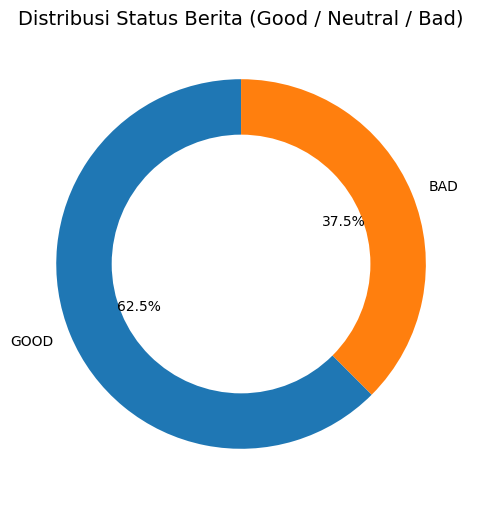

In [85]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap kategori status
status_counts = df_new['Status'].value_counts()

# Buat diagram donat
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)  # Membuat donat (lubang di tengah)
)

# Tambahkan lingkaran putih di tengah
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Judul
plt.title('Distribusi Status Berita (Good / Neutral / Bad)', fontsize=14)

# Tampilkan grafik
plt.show()


In [86]:
import torch.nn.functional as F
import torch
from torch.utils.data import Dataset
import ast
import numpy as np


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class IndoBertDataset(Dataset):
    def __init__(self, df, labels, device=None):
        self.df = df.reset_index(drop=True)
        self.labels = labels
        self.device = device

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- Ambil vector ---
        vec = row["vec_judul"]

        # Jika string format numpy array -> ubah ke np.array
        if isinstance(vec, str):
            vec = np.fromstring(vec.strip("[]"), sep=" ")

        if isinstance(vec, np.ndarray):
            x = torch.from_numpy(vec).float()
        else:
            x = torch.tensor(vec, dtype=torch.float)

        # --- Normalisasi ke 0..1 ---
        '''
        if x.numel() > 0:  # pastikan tidak kosong
            min_val, max_val = x.min(), x.max()
            if (max_val - min_val) > 0:  # hindari div 0
                x = (x - min_val) / (max_val - min_val)
        '''

        # --- Tambahkan kolom day ---
        #if "day" in row:
        #    day_val = float(row["day"])
        #    day_tensor = torch.tensor([day_val], dtype=torch.float)
        #    x = torch.cat([x, day_tensor], dim=0)

        # --- Ambil target y ---
        y = torch.tensor([float(row[label]) for label in self.labels], dtype=torch.float)

        if self.device:
            x = x.to(self.device)
            y = y.to(self.device)

        return x, y

In [87]:
label = pd.get_dummies(df_new['Status']).astype(int)
df_new = pd.concat([df_new, label], axis=1)
df_new

,day,vec_judul,Status,BAD,GOOD
0,0.1,-0.2764633893966675 0.19038888812065125 0.9985...,GOOD,0,1
1,0.1,-0.5665766000747681 0.07860113680362701 0.9901...,GOOD,0,1
2,0.2,-0.3197837471961975 0.20064499974250793 0.9984...,BAD,1,0
3,0.2,-0.5011537075042725 0.17542187869548798 0.9920...,GOOD,0,1
4,0.5,-0.4888719618320465 0.080900639295578 0.991093...,BAD,1,0
...,...,...,...,...,...
17620,0.3,-0.12572608888149261 0.2588920295238495 0.9936...,GOOD,0,1
17621,0.3,-0.5210395455360413 0.19109849631786346 0.9995...,GOOD,0,1
17622,0.3,-0.06579963117837906 -0.16820332407951355 0.99...,GOOD,0,1
17623,0.3,-0.5925623178482056 -0.0468837209045887 0.9921...,GOOD,0,1


In [88]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_new, test_size=0.2, random_state=42,shuffle=True)


from torch.utils.data import DataLoader
labels =['BAD', 'GOOD']
train_dataset = IndoBertDataset(train_df, labels, device=device)
test_dataset = IndoBertDataset(test_df, labels, device=device)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

#train_dataset.__getitem__(1)
len(test_dataset[0][1])
#train_dataset.__len__()
test_dataset[0]

(tensor([-0.5864,  0.0974,  0.9895,  0.9982,  0.0422, -0.9998,  0.2429, -0.0457,
          0.8567, -0.9217,  0.9999,  0.4176, -0.8732, -0.6672, -0.4310, -0.9936,
         -0.9779, -0.0804,  0.0170, -0.7919,  0.6453,  0.9931, -0.8504,  0.9967,
          0.9970, -0.9973, -0.0511, -0.9927,  0.9998,  0.0544,  0.6108,  0.1600,
         -0.4453,  0.5279, -0.9929,  0.9998,  0.0358,  0.2159, -0.4472, -0.1971,
          0.8182,  0.5106,  0.9525,  0.8223,  0.8055, -0.3218, -0.8107,  0.4650,
          0.5867,  0.9544,  0.8348,  0.9900,  0.8357,  0.4918, -0.2392, -0.0775,
          0.9971, -0.2801,  0.9996,  0.9443,  0.2421,  0.2828,  0.4421,  0.5653,
          0.9729,  0.8725, -0.9995,  0.7759, -0.1254, -0.9585, -0.7954,  0.2635,
         -0.3656, -0.5972,  0.9956,  0.3196,  0.6589,  0.7837, -0.4159, -0.6532,
          0.0942, -0.9938,  0.0897, -0.9868,  0.5678,  0.9507, -0.9998,  0.9995,
         -0.9005,  0.9764, -0.2975,  0.7473, -0.9492,  0.6596,  0.3417,  0.8732,
          0.9939,  0.9988,  

In [89]:
from jcopdl.callback import Callback, set_config

config = set_config({
    "labels"         : labels,
    "threshold"      : 0.5,
    "input_dim"      : len(test_dataset[0][0]),
    "hidden_dims"    : [264,64,8],
    "output_dim"     : len(test_dataset[0][1]),
    "dropout"        : 0.1,
    "activation"     : "leakyrelu",
    "early_stop_patience" : 30,
    "col_target"     : ['BAD', 'GOOD'],
    "feature_cols"   : ['vec_judul'],
})
config

Config(activation=leakyrelu, col_target=['BAD', 'GOOD'], dropout=0.1, early_stop_patience=30, feature_cols=['vec_judul'], hidden_dims=[264, 64, 8], input_dim=768, labels=['BAD', 'GOOD'], output_dim=2, threshold=0.5)

In [90]:
from class_lib import MultiLabel1DClassifier
from torch import optim, nn
from jcopdl.callback import Callback
root_folder = "multi-label-clasification"
#Model
model = MultiLabel1DClassifier(input_dim=config.input_dim, hidden_dims=config.hidden_dims, output_dim=config.output_dim, dropout=config.dropout, activation=config.activation).to(device)

#Criterion
criterion = nn.BCELoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=1.0)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 56/56 [00:01<00:00, 33.60it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6805 │ 0.6705 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4308 │ 0.3745 │ │  BAD  │  0.6255  │
│ Subset Accuracy  │ 0.3525 │ 0.6255 │ │ GOOD  │  0.6255  │
│ Micro F1         │ 0.4500 │ 0.6255 │ └───────┴──────────┘
│ Macro F1         │ 0.2959 │ 0.3848 │                     
│ Overall Accuracy │ 0.5692 │ 0.6255 │                     
└──────────────────┴────────┴────────┘


Epoch     1
Train_cost  = 0.6805 | Test_cost  = 0.6705 | Train_score = 0.5692 | Test_score = 0.6255 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

...


Epoch    19
Train_cost  = 0.6621 | Test_cost  = 0.6631 | Train_score = 0.6249 | Test_score = 0.6255 |
==> EarlyStop patience = 18 | Best test_score: 0.6255


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 56/56 [00:01<00:00, 35.15it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6620 │ 0.6630 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.3751 │ 0.3745 │ │  BAD  │  0.6255  │
│ Subset Accuracy  │ 0.6249 │ 0.6255 │ │ GOOD  │  0.6255  │
│ Micro F1         │ 0.6249 │ 0.6255 │ └───────┴──────────┘
│ Macro F1         │ 0.3846 │ 0.3848 │                     
│ Overall Accuracy │ 0.6249 │ 0.6255 │                     
└──────────────────┴────────┴────────┘


Epoch    20
Train_cost  = 0.6620 | Test_cost  = 0.6630 | Train_score = 0.6249 | Test_score = 0.6255 |


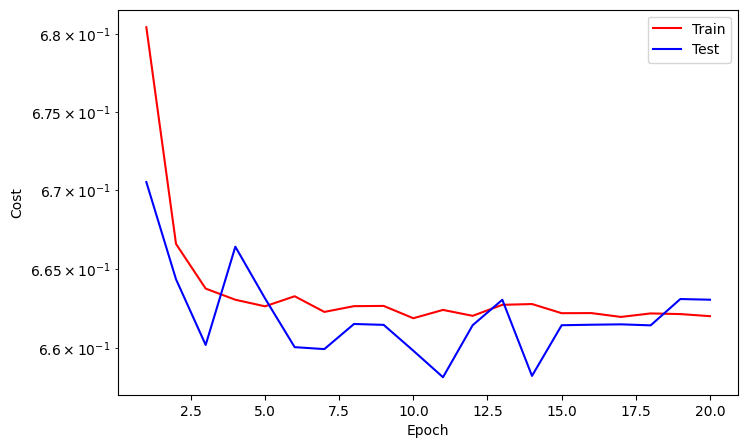

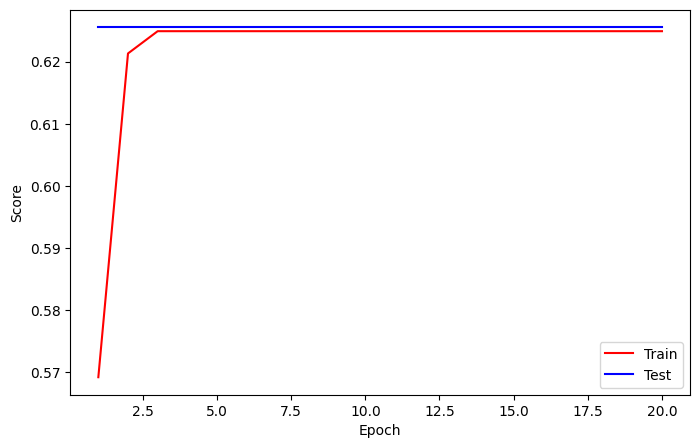

==> EarlyStop patience = 19 | Best test_score: 0.6255


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 56/56 [00:01<00:00, 38.66it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6618 │ 0.6613 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.3751 │ 0.3745 │ │  BAD  │  0.6255  │
│ Subset Accuracy  │ 0.6249 │ 0.6255 │ │ GOOD  │  0.6255  │
│ Micro F1         │ 0.6249 │ 0.6255 │ └───────┴──────────┘
│ Macro F1         │ 0.3846 │ 0.3848 │                     
│ Overall Accuracy │ 0.6249 │ 0.6255 │                     
└──────────────────┴────────┴────────┘


Epoch    21
Train_cost  = 0.6618 | Test_cost  = 0.6613 | Train_score = 0.6249 | Test_score = 0.6255 |
==> EarlyStop patience = 20 | Best test_score: 0.6255


...


Epoch    30
Train_cost  = 0.6619 | Test_cost  = 0.6596 | Train_score = 0.6249 | Test_score = 0.6255 |
==> EarlyStop patience = 29 | Best test_score: 0.6255


─────────────────────────────────────────────────── 🚀 EPOCH 31 ───────────────────────────────────────────────────

test: 100%|██████████| 56/56 [00:01<00:00, 39.03it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6616 │ 0.6645 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.3751 │ 0.3745 │ │  BAD  │  0.6255  │
│ Subset Accuracy  │ 0.6249 │ 0.6255 │ │ GOOD  │  0.6255  │
│ Micro F1         │ 0.6249 │ 0.6255 │ └───────┴──────────┘
│ Macro F1         │ 0.3846 │ 0.3848 │                     
│ Overall Accuracy │ 0.6249 │ 0.6255 │                     
└──────────────────┴────────┴────────┘


Epoch    31
Train_cost  = 0.6616 | Test_cost  = 0.6645 | Train_score = 0.6249 | Test_score = 0.6255 |
==> EarlyStop patience = 30 | Best test_score: 0.6255
==> Execute Early Stopping at epoch: 31 | Best test_score: 0.6255
==> Best model is saved at multi-label-clasification


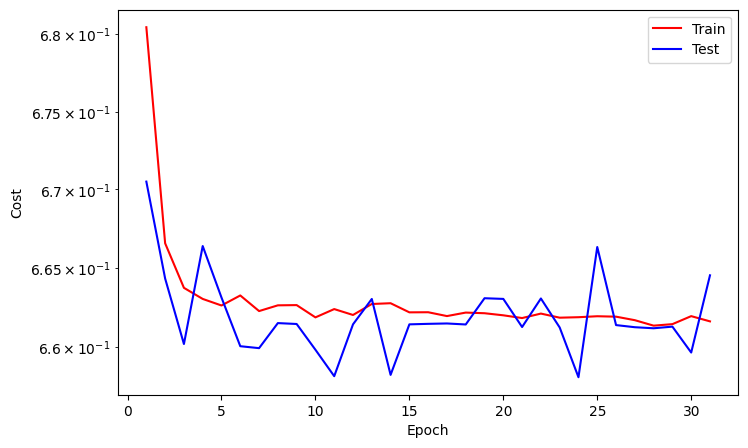

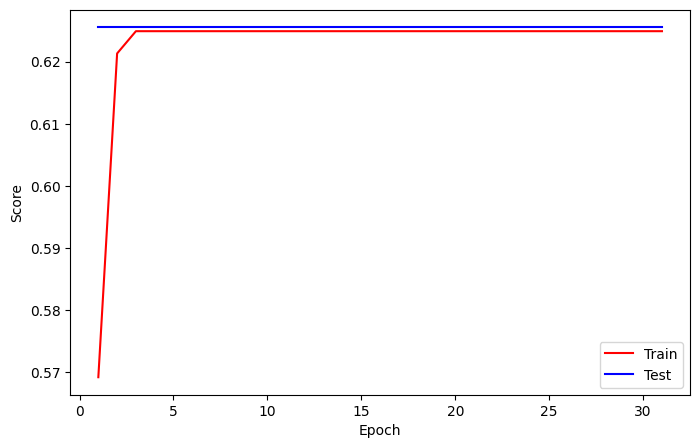

⏹️ Training dihentikan oleh early stopping.

In [91]:
from train_and_evaluate import train_and_evaluate_multi_label

train_and_evaluate_multi_label(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback
)

In [ ]:
from evaluate import evaluate_multi_label

hsl = evaluate_multi_label(model, test_loader, ['BAD', 'GOOD'],criterion, device, config.threshold)

       📊 Evaluasi Model            🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓      Accuracy      
┃ Metrik              ┃  Nilai ┃ ┏━━━━━━━┳━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Akurasi ┃
│ 🔹 Overall Accuracy │ 0.6249 │ ┡━━━━━━━╇━━━━━━━━━┩
│ ✅ Subset  Accuracy │ 0.6249 │ │  BAD  │ 0.6249  │
│ 💥 Loss (avg)       │ 0.6705 │ │ GOOD  │ 0.6249  │
│ 📉 Hamming Loss     │ 0.3751 │ └───────┴─────────┘
│ ⚖️  Micro F1-score   │ 0.6249 │                    
│ 📈 Macro F1-score   │ 0.3846 │                    
└─────────────────────┴────────┘

In [96]:
hsl['df'].head(100)

,Target,Prediksi,Benar (%)
0,"[0.0, 1.0]","[0.0, 1.0]",100.0
1,"[1.0, 0.0]","[0.0, 1.0]",0.0
2,"[0.0, 1.0]","[0.0, 1.0]",100.0
3,"[0.0, 1.0]","[0.0, 1.0]",100.0
4,"[0.0, 1.0]","[0.0, 1.0]",100.0
...,...,...,...
95,"[0.0, 1.0]","[0.0, 1.0]",100.0
96,"[0.0, 1.0]","[0.0, 1.0]",100.0
97,"[1.0, 0.0]","[0.0, 1.0]",0.0
98,"[1.0, 0.0]","[0.0, 1.0]",0.0
